# Safe-Haven 🪙
### Does gold really hedge inflation and protect you in a crash?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Gold hedges inflation?: Not supported](https://img.shields.io/badge/Gold_hedges_inflation%3F-Not_supported-8b949e?style=flat-square)

Gold's whole reputation rests on two promises: it protects against inflation, and it's a safe haven when markets crash. We checked both on 20 years of data. The inflation promise simply isn't there — gold's return barely budges with inflation. The crisis promise is half-true: gold doesn't *fall* with stocks, but it only *rises* half the time.

> 📓 **Plain-language layer.** The inflation correlation, the high/low split and the crash behaviour are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (safe_haven/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from safe_haven import data, strategy as st
gold_m, eq_ret, cpi_m = data.fetch_panel()     # cache-first (shared pulls)
ih = st.inflation_hedge(gold_m, cpi_m)
cb = st.crisis_ballast(gold_m.pct_change(), eq_ret)


## The answer first 🎯

| The question | The data (GLD/SPY/CPI, 2005–2025) |
|---|---|
| "Does gold track inflation?" | No: correlation **+0.09**; no premium when inflation is high. |
| "Does it protect in a crash?" | Partly: **−0.2% vs SPY −10%**, but up only **50%** of the time. |
| "So what is gold good for?" | A real **diversifier** that doesn't fall with stocks. |

## 1 · The claim

Two folk beliefs: *(a)* gold preserves purchasing power — when inflation rises, gold rises; *(b)* gold is a safe haven — when stocks crash, gold rallies. Together they make gold the classic 'store of value' and portfolio insurance.

## 2 · So what?

If both held, gold would be a uniquely valuable holding — insurance that also beats inflation. If they don't, then gold's role is narrower (and its high average return may be just a price trend, not a hedge). Worth knowing before you size it.

## 3 · How would we even know?

For inflation: correlate gold's yearly return with yearly CPI, and compare gold in high- vs low-inflation months. For crisis: measure gold's stock correlation and its return in the worst equity months (SPY down >8%).

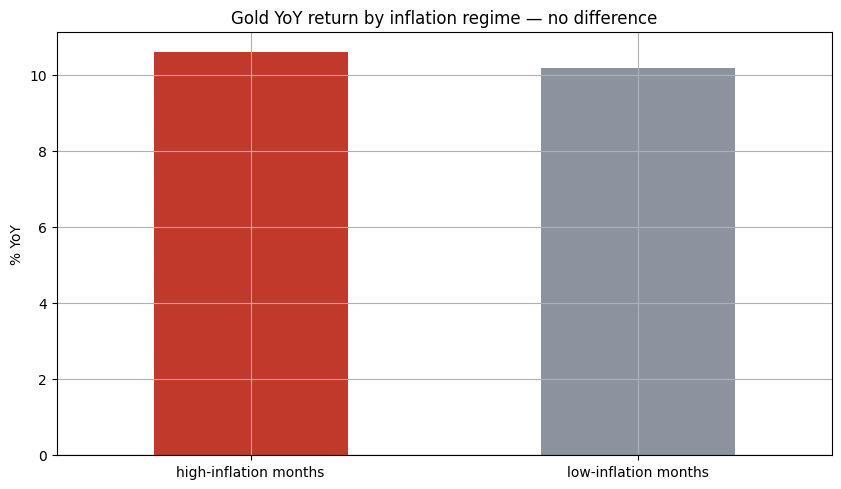

corr(gold YoY, inflation YoY) = +0.09  |  high-minus-low gap +0.4%


In [2]:
split=pd.Series({'high-inflation months':ih['gold_hi_infl'],'low-inflation months':ih['gold_lo_infl']})*100
ax=split.plot.bar(rot=0,color=['#c0392b','#8b949e'],title='Gold YoY return by inflation regime — no difference')
ax.set_ylabel('% YoY'); ax.axhline(0,color='k',lw=.8); plt.show()
print(f"corr(gold YoY, inflation YoY) = {ih['corr']:+.2f}  |  high-minus-low gap {ih['hi_minus_lo']:+.1%}")

## 4 · The teardown — no inflation link, unreliable in a crash

Gold earned ~the same when inflation was hot or cold; and in the worst equity months it was flat, not soaring.

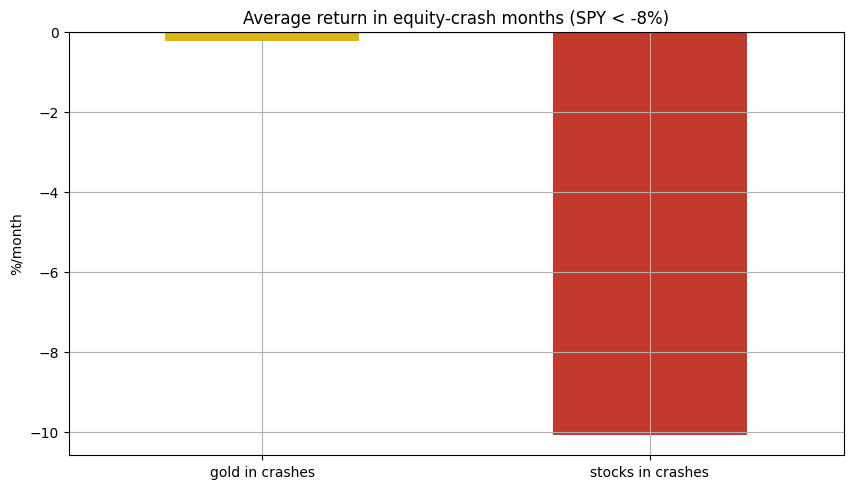

corr(gold, stocks) = +0.08  |  gold rose in 50% of 10 crash months


In [3]:
bars=pd.Series({'gold in crashes':cb['gold_in_crash'],'stocks in crashes':cb['eq_in_crash']})*100
ax=bars.plot.bar(rot=0,color=['#dab617','#c0392b'],title='Average return in equity-crash months (SPY < -8%)')
ax.set_ylabel('%/month'); ax.axhline(0,color='k',lw=.8); plt.show()
print(f"corr(gold, stocks) = {cb['stock_corr']:+.2f}  |  gold rose in {cb['gold_up_share']:.0%} of {cb['n_crash']} crash months")

**Read it plainly.** Gold's +10%/yr over this window was a price bull market (real rates, the dollar) — *not* an inflation response: it was just as strong when inflation was low. And while it didn't add to the pain in crashes, it rallied in only half of them. Useful ballast; not the inflation hedge or sure-thing haven of the legend.

## 5 · The verdict

**Signal: None** (inflation hedge) — corr +0.09, no high-inflation premium. **Tradability: Fragile** (crisis hedge) — flat but up only half the time. **Gold hedges inflation?: Not supported.**

## 6 · Could you actually trade it?

Own gold as a *diversifier* — a sleeve that's uncorrelated with stocks and tends not to fall when they do (see [68 All-Weather](../../68-all-weather/)). Just don't buy it *for* inflation protection or as guaranteed crash insurance; the data won't back you up.

## 7 · Going further 🚪

The diversifier cousin of [68 All-Weather](../../68-all-weather/) (gold as a risk-parity sleeve) and [70 Digital-Gold](../../70-digital-gold/) (bitcoin's identical pitch). Forks: very-long-horizon real gold price (Erb-Harvey), real-rate / dollar drivers, gold vs TIPS as the true inflation hedge.